# Ejercicio de programación - Regresión Logística

En este ejercicio se implementa regresión logística y se aplica a un dataset de **aprobación de préstamos** (`Loan_approval_data_2025.csv`), donde la variable objetivo `loan_status` indica si el préstamo fue aprobado (1) o no (0).


In [52]:
#from google.colab import drive
#drive.mount('/content/drive')

In [53]:
# se utiliza para el manejo de rutas y directorios.
import os

# Calculo cientifico y vectorial para python
import numpy as np

# Manejo de datos tabulares (lectura del csv, codificacion de columnas categoricas)
import pandas as pd

# Librerias para graficar
from matplotlib import pyplot

# Modulo de optimización de scipy
from scipy import optimize

# le dice a matplotlib que incruste gráficos en el cuaderno
%matplotlib inline

## 1 Regresión Logística

En esta parte del ejercicio, se construye un modelo de regresión logística para predecir si una solicitud de préstamo será **aprobada**. Se cuenta con datos históricos de solicitantes (`Loan_approval_data_2025.csv`) que incluyen información demográfica, laboral, crediticia y del préstamo solicitado. Para cada solicitante se conoce si el préstamo fue finalmente aprobado (`loan_status = 1`) o no (`loan_status = 0`). La tarea es crear un modelo de clasificación que calcule la probabilidad de aprobación en función de las características del solicitante.

### 1.0 Ajuste del dataset (`Loan_approval_data_2025.csv` -> matriz numérica `X`, `y`)

A diferencia del dataset original (todo numérico, sin encabezados), este dataset tiene:
- Una columna identificadora (`customer_id`) que **no aporta información predictiva** y se descarta.
- Columnas categóricas de texto (`occupation_status`, `product_type`, `loan_intent`) que deben convertirse a variables numéricas (codificación *one-hot* / *dummy*) antes de poder usarlas en el modelo.
- Columnas numéricas que se usan directamente.
- La columna `loan_status` es la etiqueta `y`.

La siguiente celda carga el csv, descarta el identificador, codifica las columnas categóricas y arma las matrices `X` (variables) e `y` (etiqueta):


In [54]:
# Ruta al archivo csv. Si se sube el archivo directamente a Colab (panel de archivos), usar solo el nombre:
DATA_PATH = 'Loan_approval_data_2025.csv'
# Si se guarda en Google Drive, ajustar la ruta segun la carpeta utilizada, por ejemplo:
#DATA_PATH = '/content/drive/MyDrive/Colab Notebooks/machine learning/datasets/Loan_approval_data_2025.csv'

df = pd.read_csv(DATA_PATH)

# customer_id es solo un identificador, no aporta informacion predictiva -> se descarta
df = df.drop(columns=['customer_id'])

# columnas categoricas (texto) que deben convertirse a variables numericas (dummies / one-hot)
columnas_categoricas = ['occupation_status', 'product_type', 'loan_intent']

# separa la etiqueta (variable objetivo) del resto de columnas
y = df['loan_status'].to_numpy(dtype=float)
X_df = df.drop(columns=['loan_status'])

# convierte las columnas categoricas en columnas binarias (0/1)
X_df = pd.get_dummies(X_df, columns=columnas_categoricas, drop_first=True)

# nombres de las columnas finales, en el mismo orden en que quedan en X (util para interpretar theta luego)
nombres_columnas = X_df.columns.tolist()

# convierte todo a un arreglo numpy de tipo float, tal como lo espera el resto del cuaderno
X = X_df.to_numpy(dtype=float)

print('X shape:', X.shape)
print('y shape:', y.shape)
print('Columnas de X:', nombres_columnas)

X shape: (50000, 24)
y shape: (50000,)
Columnas de X: ['age', 'years_employed', 'annual_income', 'credit_score', 'credit_history_years', 'savings_assets', 'current_debt', 'defaults_on_file', 'delinquencies_last_2yrs', 'derogatory_marks', 'loan_amount', 'interest_rate', 'debt_to_income_ratio', 'loan_to_income_ratio', 'payment_to_income_ratio', 'occupation_status_Self-Employed', 'occupation_status_Student', 'product_type_Line of Credit', 'product_type_Personal Loan', 'loan_intent_Debt Consolidation', 'loan_intent_Education', 'loan_intent_Home Improvement', 'loan_intent_Medical', 'loan_intent_Personal']


### 1.1 División en entrenamiento (80%) y prueba (20%)

Para poder validar el modelo de forma honesta, el **20% de los datos se aparta como conjunto de prueba antes de cualquier entrenamiento**, y esos ejemplos **no se usan en ningún momento durante el entrenamiento** (ni para ajustar `theta`, ni para calcular la media/desviación estándar de la normalización). El otro 80% se usa exclusivamente para entrenar.

La división se hace de forma aleatoria (usando una semilla fija para que el resultado sea reproducible) para evitar que algún orden particular de las filas del csv (por ejemplo, por `customer_id`) sesgue los conjuntos.


In [55]:
# semilla fija para que la particion sea reproducible
np.random.seed(42)

m_total = X.shape[0]

# genera una permutacion aleatoria de los indices de todas las filas
indices = np.random.permutation(m_total)

# 80% de los indices para entrenamiento, 20% para prueba
m_train = int(0.8 * m_total)

train_idx = indices[:m_train]
test_idx = indices[m_train:]

# los indices de train y test son disjuntos por construccion (particion de 'indices'),
# por lo que ningun ejemplo de prueba es usado en el entrenamiento
assert len(np.intersect1d(train_idx, test_idx)) == 0

X_train, y_train = X[train_idx], y[train_idx]
X_test, y_test = X[test_idx], y[test_idx]

print('Ejemplos totales:', m_total)
print('Ejemplos de entrenamiento (80%):', X_train.shape[0])
print('Ejemplos de prueba (20%):', X_test.shape[0])

Ejemplos totales: 50000
Ejemplos de entrenamiento (80%): 40000
Ejemplos de prueba (20%): 10000


### 1.2 Visualizar los datos

Antes de comenzar a implementar cualquier algoritmo de aprendizaje, siempre es bueno visualizar los datos si es posible. Como ahora se tienen muchas variables (no solo 2 como en el ejemplo original de admisión), se grafican dos variables numéricas representativas (`credit_score` y `annual_income`) del conjunto de **entrenamiento**, distinguiendo con marcadores distintos los préstamos aprobados y no aprobados.


In [56]:
def plotData(X, y, xlabel_idx, ylabel_idx):
    # Grafica los puntos de datos X y y en una nueva figura. Grafica los puntos de datos con * para los positivos y
    # o para los negativos.

    # Crea una nueva figura
    fig = pyplot.figure()

    # Find Indices of Positive and Negative Examples
    pos = y == 1
    neg = y == 0

    # Plot Examples
    pyplot.plot(X[pos, xlabel_idx], X[pos, ylabel_idx], 'k*', lw=2, ms=6)
    pyplot.plot(X[neg, xlabel_idx], X[neg, ylabel_idx], 'ko', mfc='y', ms=5, mec='k', mew=1)

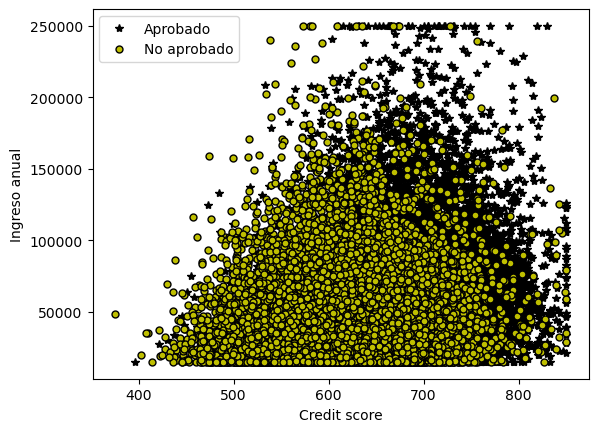

In [57]:
idx_credit_score = nombres_columnas.index('credit_score')
idx_annual_income = nombres_columnas.index('annual_income')

plotData(X_train, y_train, idx_credit_score, idx_annual_income)
# adiciona etiquetas para los ejes
pyplot.xlabel('Credit score')
pyplot.ylabel('Ingreso anual')
pyplot.legend(['Aprobado', 'No aprobado'])
pass

<a id="section1"></a>
### 1.3 Implementación

#### 1.3.1 Función Sigmoidea

La hipótesis para la regresión logística se define como:

$$ h_\theta(x) = g(\theta^T x)$$

donde la función $g$ es la función sigmoidea. La función sigmoidea se define como:

$$g(z) = \frac{1}{1+e^{-z}}$$.

Los resultados que debe generar la función sigmoidea para valores positivos amplios de `x`, deben ser cercanos a 1, mientras que para valores negativos grandes, la sigmoide debe generar valores cercanos 0. La evaluación de `sigmoid(0)` debe dar un resultado exacto de 0.5. Esta función también debe poder trabajar con vectores y matrices.


In [58]:
def sigmoid(z):
    # Calcula la sigmoide de una entrada z
    # convierte la intrada a un arreglo numpy
    z = np.array(z)

    g = np.zeros(z.shape)

    g = 1 / (1 + np.exp(-z))

    return g

Se calcula el valor de la sigmoide aplicando la función sigmoid con `z=0`, se debe obtener un resultado de 0.5. Se recomienda experimentar con otros valores de `z`.


In [59]:
# Prueba la implementacion de la funcion sigmoid
z = [0, 0.5, 0.75, 1]
g = sigmoid(z)

print('g(', z, ') = ', g)

g( [0, 0.5, 0.75, 1] ) =  [0.5        0.62245933 0.6791787  0.73105858]


#### 1.3.2 Normalización de características

Las variables del dataset tienen escalas muy distintas (por ejemplo `age` vs `annual_income`), por lo que se normalizan (media 0, desviación estándar 1) antes de entrenar. **Importante para evitar fuga de información (*data leakage*):** la media (`mu`) y la desviación estándar (`sigma`) se calculan **únicamente con el conjunto de entrenamiento**, y esos mismos valores se aplican después para normalizar el conjunto de prueba. De esta forma el conjunto de prueba nunca influye en ningún cálculo usado durante el entrenamiento.


In [60]:
def featureNormalize(X, mu=None, sigma=None):
    # Si no se proveen mu y sigma, se calculan a partir de X (se usa esto SOLO con el conjunto de entrenamiento).
    # Si se proveen (calculados previamente con el conjunto de entrenamiento), se usan para normalizar X
    # (se usa esto con el conjunto de prueba, para no filtrar informacion del test al entrenamiento).
    X_norm = X.copy()

    if mu is None or sigma is None:
        mu = np.mean(X, axis=0)
        sigma = np.std(X, axis=0)

    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [61]:
# mu y sigma se calculan SOLO con los datos de entrenamiento
X_train_norm, mu, sigma = featureNormalize(X_train)

# los datos de prueba se normalizan reutilizando el mu y sigma del entrenamiento (no se recalculan con el test)
X_test_norm, _, _ = featureNormalize(X_test, mu, sigma)

In [62]:
print(X_train_norm)

[[-0.44618543 -0.22911559 -0.16082898 ... -0.41773385  2.36083491
  -0.57534878]
 [-0.71608558 -0.41350386 -0.04734938 ... -0.41773385 -0.42357896
  -0.57534878]
 [-1.25588587 -0.84813335  0.16680652 ... -0.41773385 -0.42357896
  -0.57534878]
 ...
 [ 1.89294918  1.94403186 -0.0273615  ... -0.41773385 -0.42357896
   1.73807616]
 [-1.52578602 -0.97983926 -0.32911407 ... -0.41773385 -0.42357896
   1.73807616]
 [ 1.17321545  0.69282575  0.28483021 ...  2.39386872 -0.42357896
  -0.57534878]]


<a id="section2"></a>
#### 1.3.3 Función de Costo y Gradiente

Se implementa la función cost y gradient, para la regresión logística. Antes de continuar es importante agregar el término de intercepción a `X`.


In [63]:
# Configurar la matriz adecuadamente, y agregar una columna de unos que corresponde al termino de intercepción.
m, n = X_train_norm.shape
# Agrega el termino de intercepción a X_train
X_train_final = np.concatenate([np.ones((m, 1)), X_train_norm], axis=1)

# lo mismo para X_test, usando la misma cantidad de filas de X_test
m_test, _ = X_test_norm.shape
X_test_final = np.concatenate([np.ones((m_test, 1)), X_test_norm], axis=1)

print('X_train_final shape:', X_train_final.shape)
print('X_test_final shape:', X_test_final.shape)

X_train_final shape: (40000, 25)
X_test_final shape: (10000, 25)


La función de costo en una regresión logística es:

$$ J(\theta) = \frac{1}{m} \sum_{i=1}^{m} \left[ -y^{(i)} \log\left(h_\theta\left( x^{(i)} \right) \right) - \left( 1 - y^{(i)}\right) \log \left( 1 - h_\theta\left( x^{(i)} \right) \right) \right]$$

y el gradiente del costo es un vector de la misma longitud como $\theta$ donde el elemento $j^{th}$ (para $j = 0, 1, \cdots , n$) se define como:

$$ \frac{\partial J(\theta)}{\partial \theta_j} = \frac{1}{m} \sum_{i=1}^m \left( h_\theta \left( x^{(i)} \right) - y^{(i)} \right) x_j^{(i)} $$

Si bien este gradiente parece idéntico al gradiente de regresión lineal, la fórmula es diferente porque la regresión lineal y logística tienen diferentes definiciones de $h_\theta(x)$.
<a id="costFunction"></a>


In [64]:
def calcularCosto(theta, X, y):
    # Inicializar algunos valores utiles
    m = y.size  # numero de ejemplos de entrenamiento

    J = 0
    h = sigmoid(X.dot(theta.T))
    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))

    return J

In [65]:
def descensoGradiente(theta, X, y, alpha, num_iters):
    # Inicializa algunos valores
    m = y.shape[0] # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual será acutalizada por el descenso por el gradiente
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        h = sigmoid(X.dot(theta.T))
        theta = theta - (alpha / m) * (h - y).dot(X)

        J_history.append(calcularCosto(theta, X, y))
    return theta, J_history

Se entrena el modelo **únicamente con el conjunto de entrenamiento** (`X_train_final`, `y_train`). El número de parámetros de `theta` se ajusta automáticamente a la cantidad de columnas de `X_train_final` (intercepto + todas las variables, incluidas las categóricas ya codificadas).


theta calculado por el descenso por el gradiente: [ 0.25239692  0.10319988  0.25326343  0.367824    1.4057088   0.66673714
  0.10606493 -0.46265639 -1.33632755 -0.73832956 -0.49070655  0.08057371
 -0.40513356 -1.23996912 -0.4356097  -0.43552458  0.00427147  0.04993555
 -0.68980119 -0.62446392 -0.29630643  0.84450556  0.20215467  0.217917
  0.61414316]


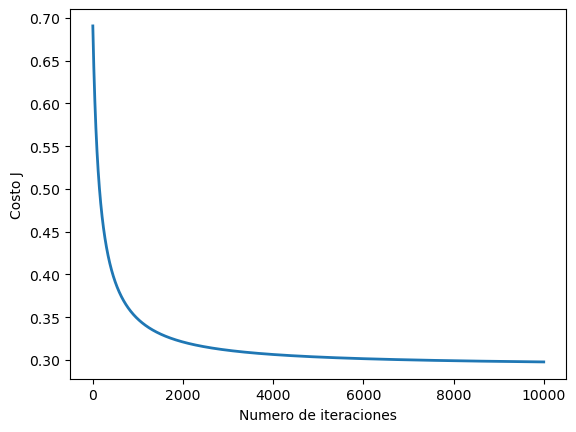

In [66]:
# Elegir algun valor para alpha (probar varias alternativas)
alpha = 0.01
num_iters = 10000

# inicializa theta (tamaño = numero de columnas de X_train_final) y ejecuta el descenso por el gradiente
theta = np.zeros(X_train_final.shape[1])
theta, J_history = descensoGradiente(theta, X_train_final, y_train, alpha, num_iters)

# Grafica la convergencia del costo
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')

# Muestra los resultados del descenso por el gradiente
print('theta calculado por el descenso por el gradiente: {:s}'.format(str(theta)))

### 1.4 Validación del modelo con el conjunto de prueba (20%)

Se evalúa el modelo entrenado sobre `X_test_final` / `y_test`, es decir, sobre el 20% de los datos que **no se usaron en ningún paso del entrenamiento** (ni para ajustar `theta`, ni para calcular `mu`/`sigma` de la normalización). Se calcula la probabilidad de aprobación para cada solicitante de prueba y se compara la predicción (umbral 0.5) contra el valor real de `loan_status`.


In [67]:
# probabilidad de aprobacion (loan_status = 1) para cada ejemplo del conjunto de prueba
prob_test = sigmoid(np.dot(X_test_final, theta))

# se convierte la probabilidad en una prediccion binaria usando un umbral de 0.5
pred_test = (prob_test >= 0.5).astype(int)

print('Primeras probabilidades predichas:', prob_test[:10])
print('Primeras predicciones (0/1):      ', pred_test[:10])
print('Primeros valores reales (0/1):    ', y_test[:10].astype(int))

Primeras probabilidades predichas: [0.91084809 0.69931181 0.01621137 0.0028362  0.80499029 0.56043847
 0.97879406 0.9883386  0.83050932 0.93748138]
Primeras predicciones (0/1):       [1 1 0 0 1 1 1 1 1 1]
Primeros valores reales (0/1):     [1 1 0 0 1 1 1 1 1 1]


In [68]:
exactitud = np.mean(pred_test == y_test) * 100
print('Exactitud (accuracy) del modelo sobre el 20% de datos de prueba: {:.2f}%'.format(exactitud))

# Matriz de confusion simple, calculada a mano
VP = np.sum((pred_test == 1) & (y_test == 1))  # verdaderos positivos
VN = np.sum((pred_test == 0) & (y_test == 0))  # verdaderos negativos
FP = np.sum((pred_test == 1) & (y_test == 0))  # falsos positivos
FN = np.sum((pred_test == 0) & (y_test == 1))  # falsos negativos

print('Matriz de confusion (conjunto de prueba):')
print('                Predicho 0   Predicho 1')
print('Real 0 (no aprob.)   {:6d}       {:6d}'.format(VN, FP))
print('Real 1 (aprobado)    {:6d}       {:6d}'.format(FN, VP))

Exactitud (accuracy) del modelo sobre el 20% de datos de prueba: 86.35%
Matriz de confusion (conjunto de prueba):
                Predicho 0   Predicho 1
Real 0 (no aprob.)     3768          737
Real 1 (aprobado)       628         4867
